In [1]:
# Crear dataset con problemas realistas:
import pandas as pd
import numpy as np
from scipy import stats

In [2]:
# Crear dataset con missing values y outliers
np.random.seed(42)
n = 1000

datos = pd.DataFrame({
    'id': range(1, n+1),
    'edad': np.random.normal(35, 10, n).clip(18, 80),  # Normal con límites
    'salario': np.random.lognormal(10, 0.5, n),  # Distribución log-normal
    'horas_trabajo': np.random.normal(40, 5, n).clip(20, 60),
    'satisfaccion': np.random.randint(1, 6, n),
    'departamento': np.random.choice(['IT', 'Ventas', 'Marketing', 'HR'], n)
})

In [3]:
datos

,id,edad,salario,horas_trabajo,satisfaccion,departamento
0,1,39.967142,44341.562353,36.624109,4,Ventas
1,2,33.617357,34972.483357,39.277407,2,HR
2,3,41.476885,22693.077136,36.037900,1,Marketing
3,4,50.230299,15939.117886,38.460192,2,Ventas
4,5,32.658466,31229.288168,30.531927,5,Marketing
...,...,...,...,...,...,...
995,996,32.188997,37611.875571,40.387403,1,Ventas
996,997,52.976865,21736.309072,41.288763,4,HR
997,998,41.408429,14172.555672,33.791197,3,IT
998,999,29.288210,20301.834249,41.670882,1,Ventas


In [4]:
# Ajustes de formato
datos['edad'] = datos['edad'].astype(int)          # entero
datos['horas_trabajo'] = datos['horas_trabajo'].round(2)  # 2 decimales

print(datos.head())



   id  edad       salario  horas_trabajo  satisfaccion departamento
0   1    39  44341.562353          36.62             4       Ventas
1   2    33  34972.483357          39.28             2           HR
2   3    41  22693.077136          36.04             1    Marketing
3   4    50  15939.117886          38.46             2       Ventas
4   5    32  31229.288168          30.53             5    Marketing


In [5]:
# Introducir missing values
mask_missing = np.random.random(n) < 0.1  # 10% missing
datos.loc[mask_missing, 'salario'] = np.nan

mask_missing_horas = np.random.random(n) < 0.05  # 5% missing
datos.loc[mask_missing_horas, 'horas_trabajo'] = np.nan

In [6]:
# Introducir outliers
outlier_indices = np.random.choice(n, 20, replace=False)
datos.loc[outlier_indices[:10], 'salario'] = datos.loc[outlier_indices[:10], 'salario'] * 10  # Salarios extremos altos
datos.loc[outlier_indices[10:], 'horas_trabajo'] = np.random.choice([80, 90, 100], 10)  # Horas imposibles


In [7]:
print(f"Dataset creado: {datos.shape}")
print(f"Valores faltantes por columna:\n{datos.isnull().sum()}")

Dataset creado: (1000, 6)
Valores faltantes por columna:
id                0
edad              0
salario          95
horas_trabajo    46
satisfaccion      0
departamento      0
dtype: int64


In [8]:
# Analizar datos faltantes:
# Análisis detallado de missing values
print("Porcentaje de datos faltantes:")
print((datos.isnull().sum() / len(datos) * 100).round(2))


Porcentaje de datos faltantes:
id               0.0
edad             0.0
salario          9.5
horas_trabajo    4.6
satisfaccion     0.0
departamento     0.0
dtype: float64


Note: you may need to restart the kernel to use updated packages.


<Axes: >

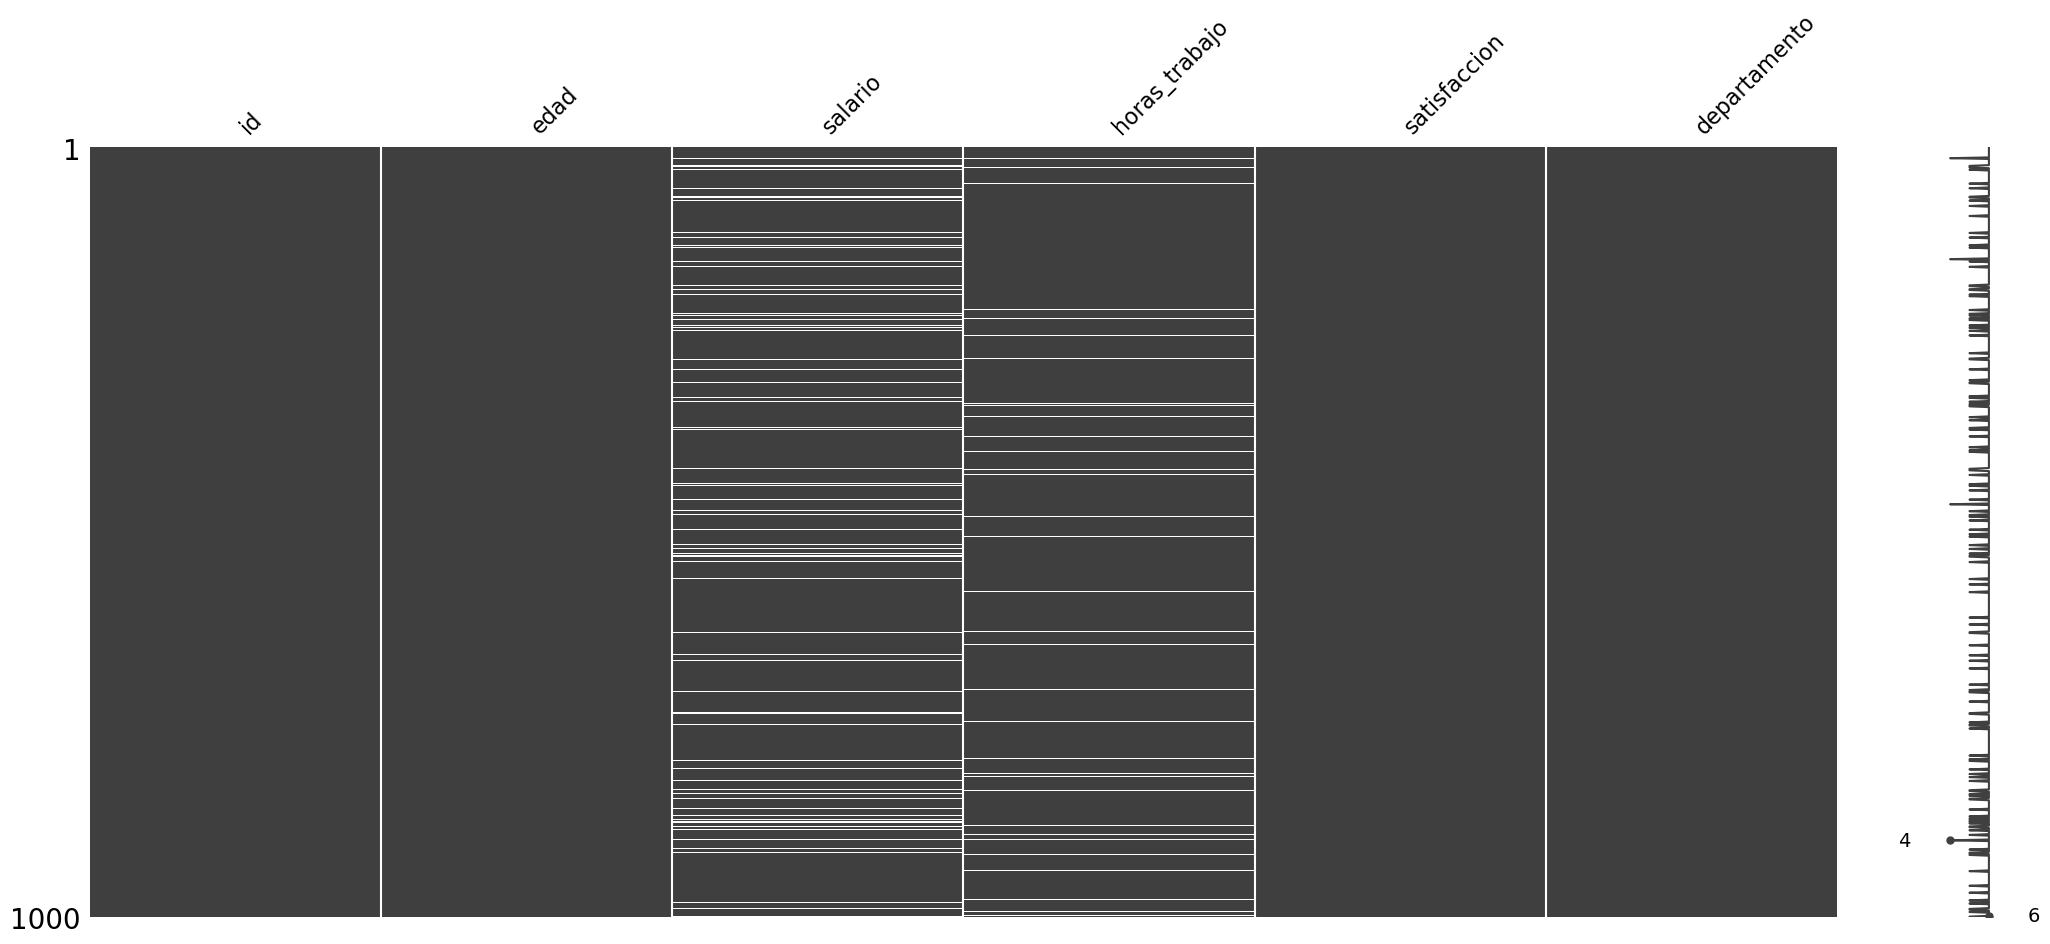

In [12]:
%pip install missingno
# Patrón de missing values
import missingno as msno
msno.matrix(datos)  # Visualización (requiere instalar missingno)

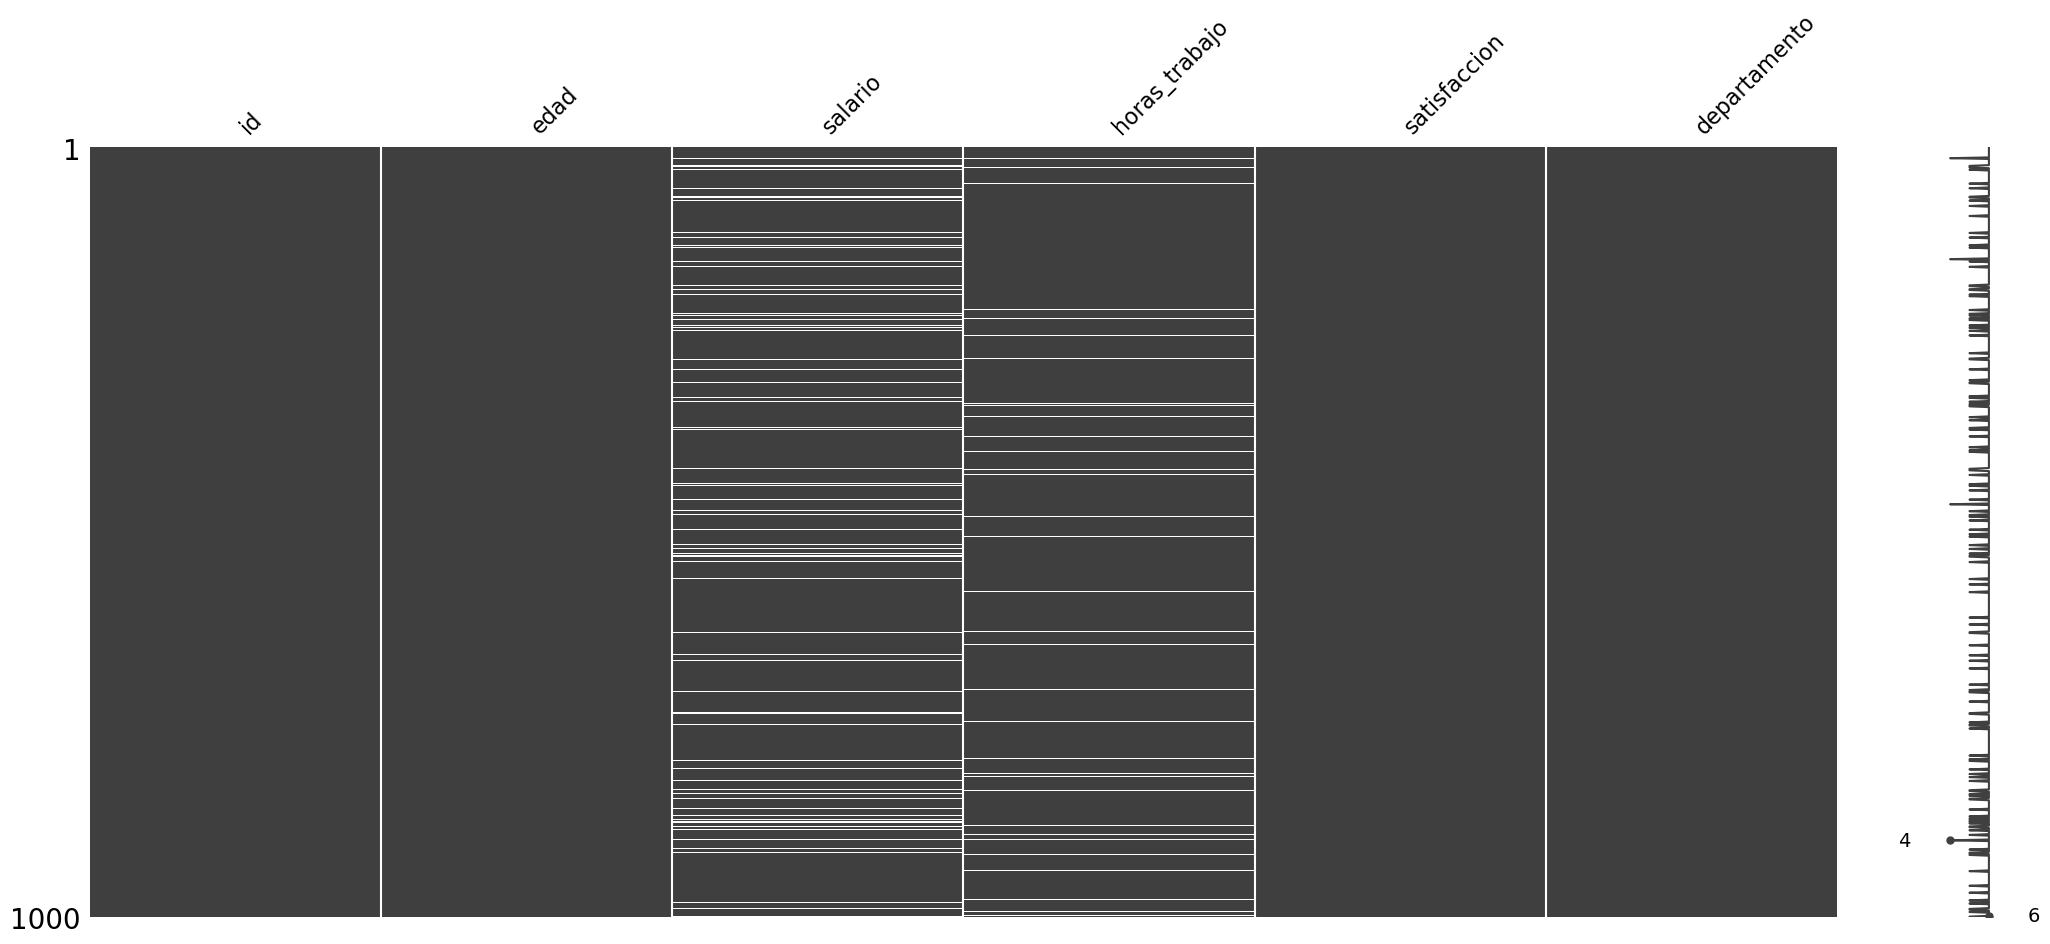

In [13]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(datos)
plt.show()


In [14]:
# Análisis por departamento
print("\nMissing values por departamento:")
print(datos.groupby('departamento').apply(lambda x: x.isnull().sum()))


Missing values por departamento:
              id  edad  salario  horas_trabajo  satisfaccion  departamento
departamento                                                              
HR             0     0       20             13             0             0
IT             0     0       18              3             0             0
Marketing      0     0       23             17             0             0
Ventas         0     0       34             13             0             0


In [15]:
# Imputación de valores faltantes:
# Imputación por media para horas_trabajo
media_horas = datos['horas_trabajo'].mean()
datos['horas_trabajo'] = datos['horas_trabajo'].fillna(media_horas)

# Imputación por mediana para salario (más robusto a outliers)
mediana_salario = datos['salario'].median()
datos['salario'] = datos['salario'].fillna(mediana_salario)

# Verificar que no queden missing values
print(f"\nValores faltantes después de imputación: {datos.isnull().sum().sum()}")


Valores faltantes después de imputación: 0


In [16]:
# Detección de outliers:
# Función para detectar outliers usando IQR
def detectar_outliers_iqr(data, columna):
    Q1 = data[columna].quantile(0.25)
    Q3 = data[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    return (data[columna] < limite_inferior) | (data[columna] > limite_superior)

# Detectar outliers en salario y horas
outliers_salario = detectar_outliers_iqr(datos, 'salario')
outliers_horas = detectar_outliers_iqr(datos, 'horas_trabajo')

print(f"\nOutliers detectados:")
print(f"Salario: {outliers_salario.sum()} ({outliers_salario.mean()*100:.1f}%)")
print(f"Horas trabajo: {outliers_horas.sum()} ({outliers_horas.mean()*100:.1f}%)")


Outliers detectados:
Salario: 55 (5.5%)
Horas trabajo: 24 (2.4%)


In [17]:
# Manejo de outliers:
# Para horas_trabajo: cap at reasonable maximum
max_horas_normales = 60
datos.loc[datos['horas_trabajo'] > max_horas_normales, 'horas_trabajo'] = max_horas_normales

# Para salario: transformar usando log (más robusto)
datos['salario_log'] = np.log1p(datos['salario'])

# Comparar estadísticas antes y después
print(f"\nEstadísticas de salario original:")
print(datos['salario'].describe().round(2))

print(f"\nEstadísticas de salario transformado (log):")
print(datos['salario_log'].describe().round(2))

# Verificar reducción de outliers
outliers_salario_log = detectar_outliers_iqr(datos, 'salario_log')
print(f"\nOutliers en salario log-transformado: {outliers_salario_log.sum()}")


Estadísticas de salario original:
count      1000.00
mean      28034.05
std       31587.51
min        5063.46
25%       17302.19
50%       22873.10
75%       30819.42
max      518367.29
Name: salario, dtype: float64

Estadísticas de salario transformado (log):
count    1000.00
mean       10.06
std         0.53
min         8.53
25%         9.76
50%        10.04
75%        10.34
max        13.16
Name: salario_log, dtype: float64

Outliers en salario log-transformado: 29


C:\Users\mfram\anaconda31\Lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
C:\Users\mfram\anaconda31\Lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


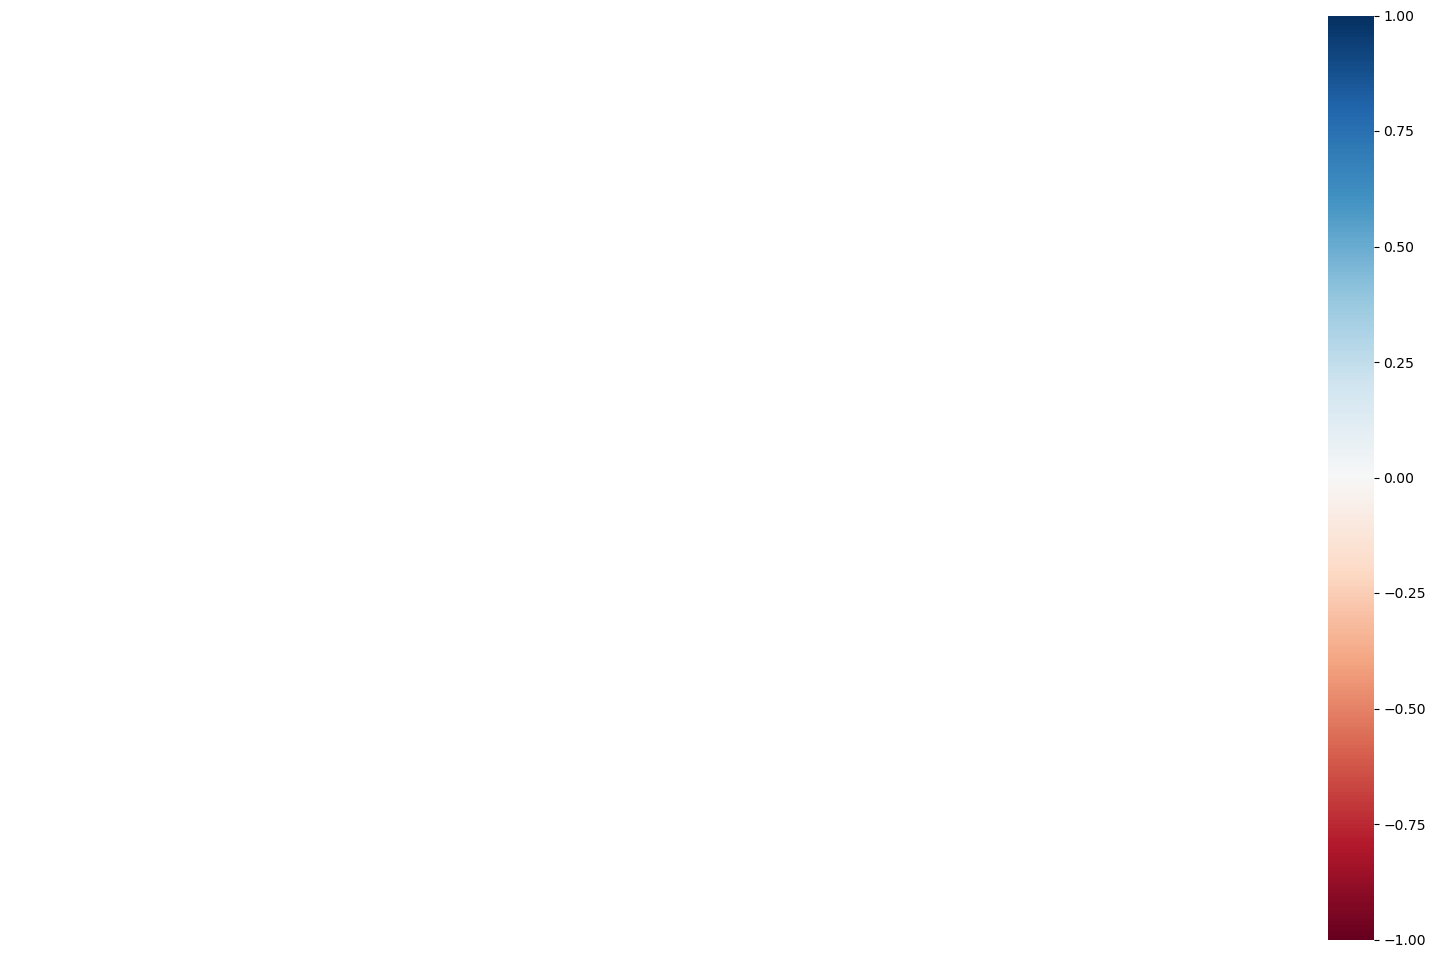

In [18]:
msno.heatmap(datos)
plt.show()

In [19]:
print(datos.shape)

(1000, 7)


In [20]:
datos

,id,edad,salario,horas_trabajo,satisfaccion,departamento,salario_log
0,1,39,44341.562353,36.620000,4,Ventas,10.699700
1,2,33,34972.483357,39.280000,2,HR,10.462345
2,3,41,22693.077136,36.040000,1,Marketing,10.029859
3,4,50,15939.117886,38.460000,2,Ventas,9.676594
4,5,32,31229.288168,30.530000,5,Marketing,10.349144
...,...,...,...,...,...,...,...
995,996,32,37611.875571,40.390000,1,Ventas,10.535102
996,997,52,21736.309072,41.290000,4,HR,9.986785
997,998,41,14172.555672,33.790000,3,IT,9.559133
998,999,29,20301.834249,40.503962,1,Ventas,9.918516


In [21]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

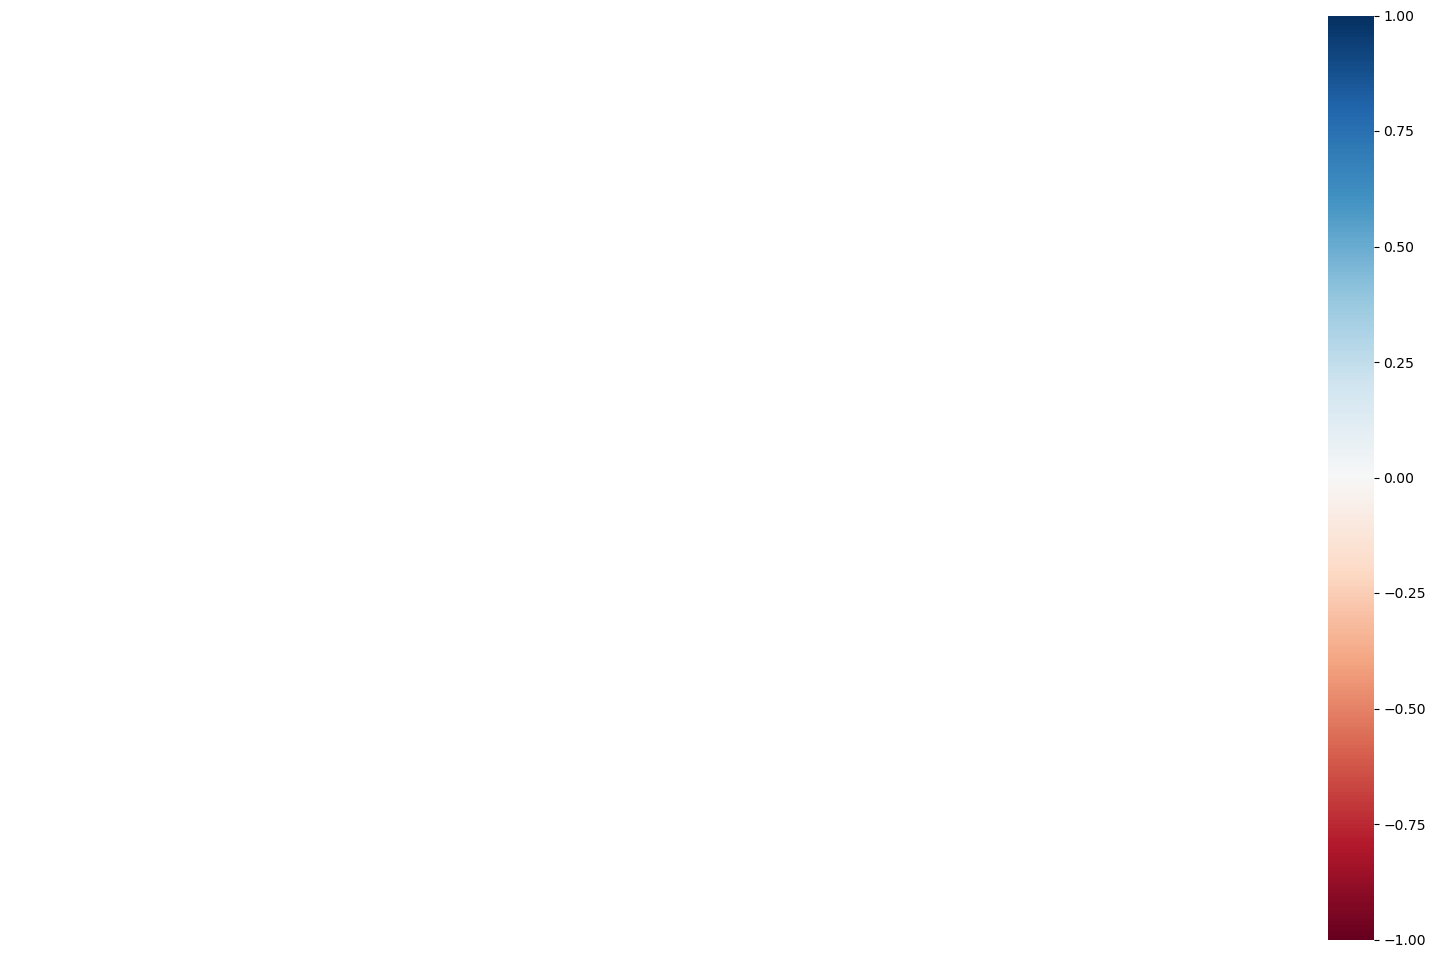

In [22]:
msno.heatmap(datos)
plt.show()

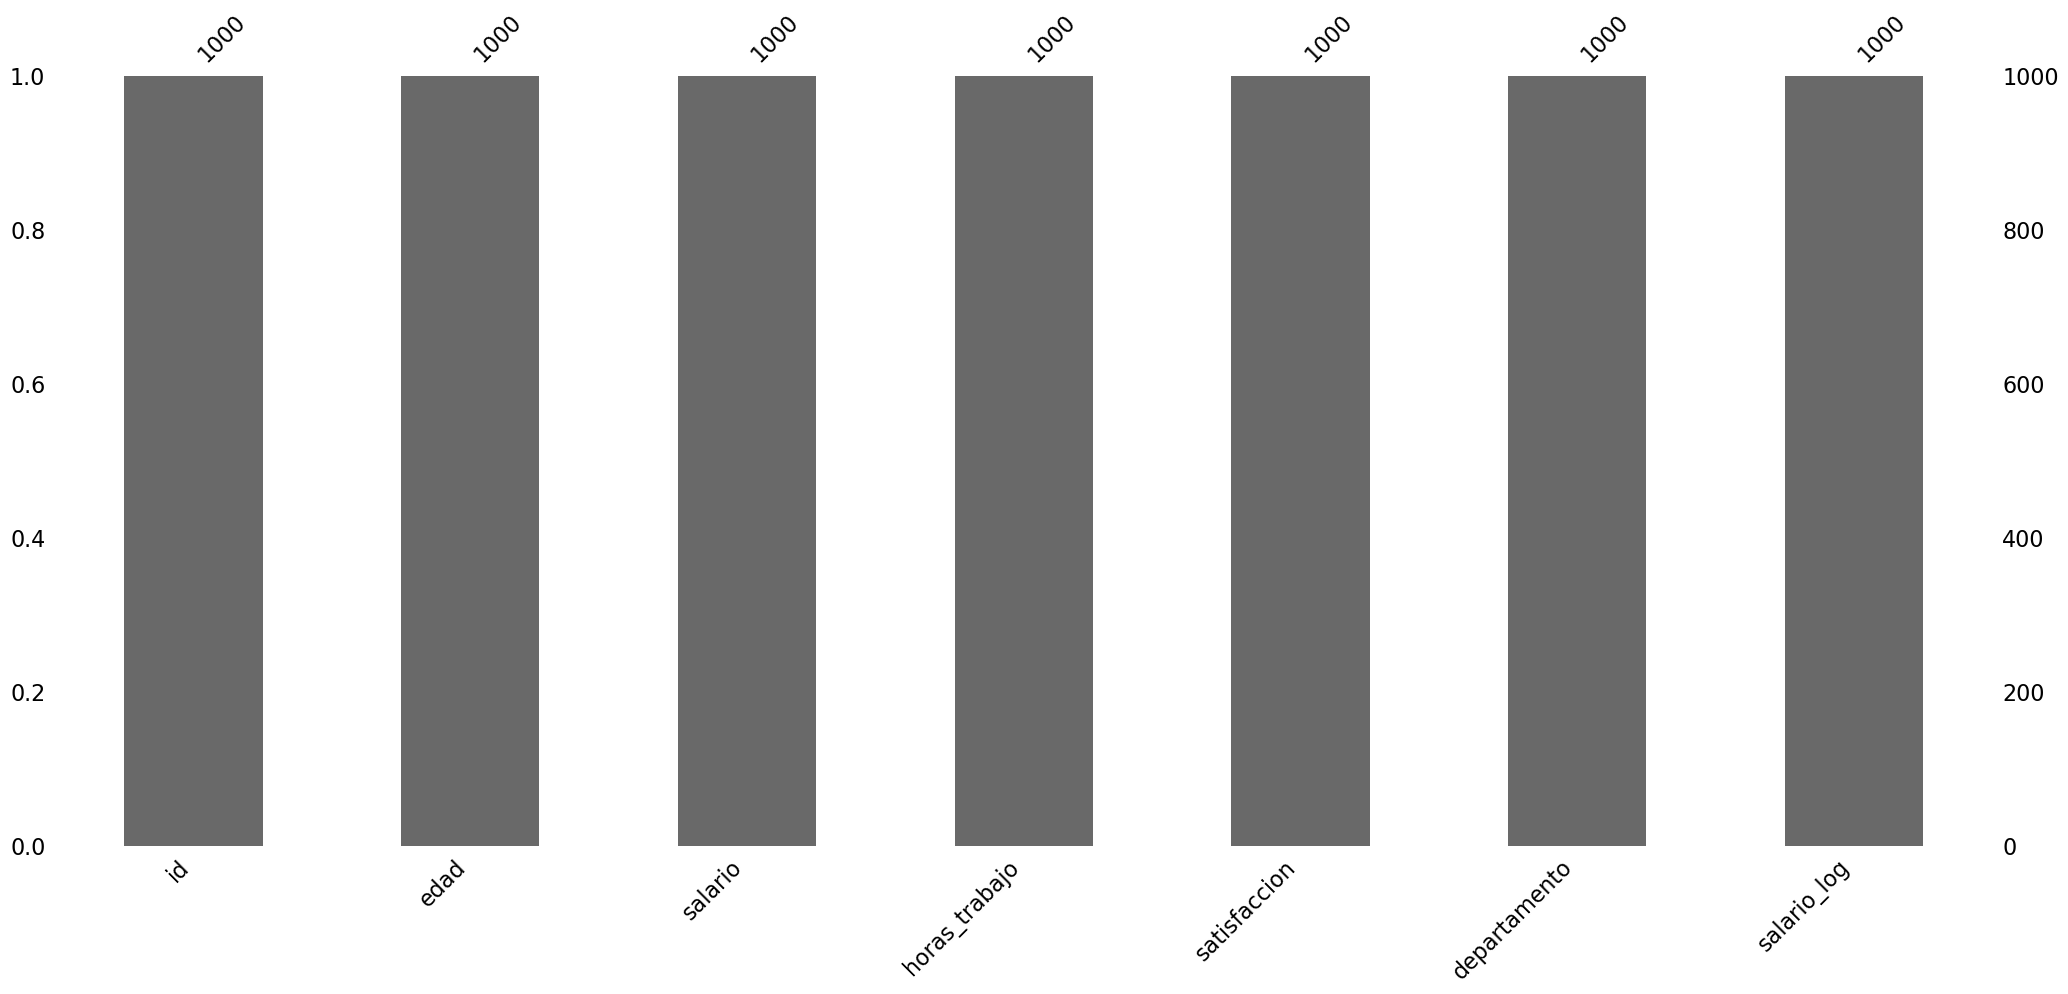

In [23]:
msno.bar(datos)
plt.show()

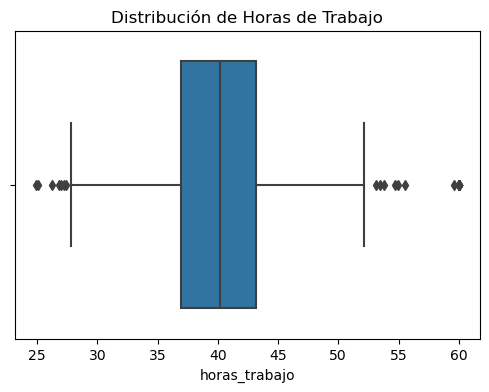

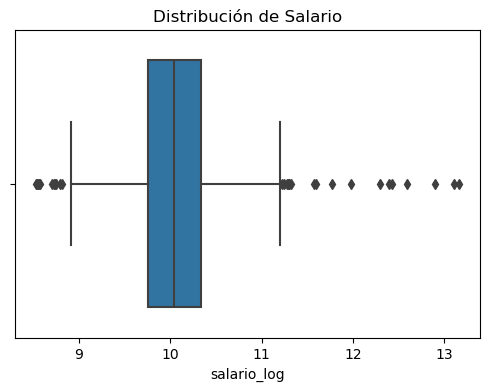

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot para horas_trabajo
plt.figure(figsize=(6,4))
sns.boxplot(x=datos['horas_trabajo'])
plt.title("Distribución de Horas de Trabajo")
plt.show()

# Boxplot para salario
plt.figure(figsize=(6,4))
sns.boxplot(x=datos['salario_log'])
plt.title("Distribución de Salario")
plt.show()

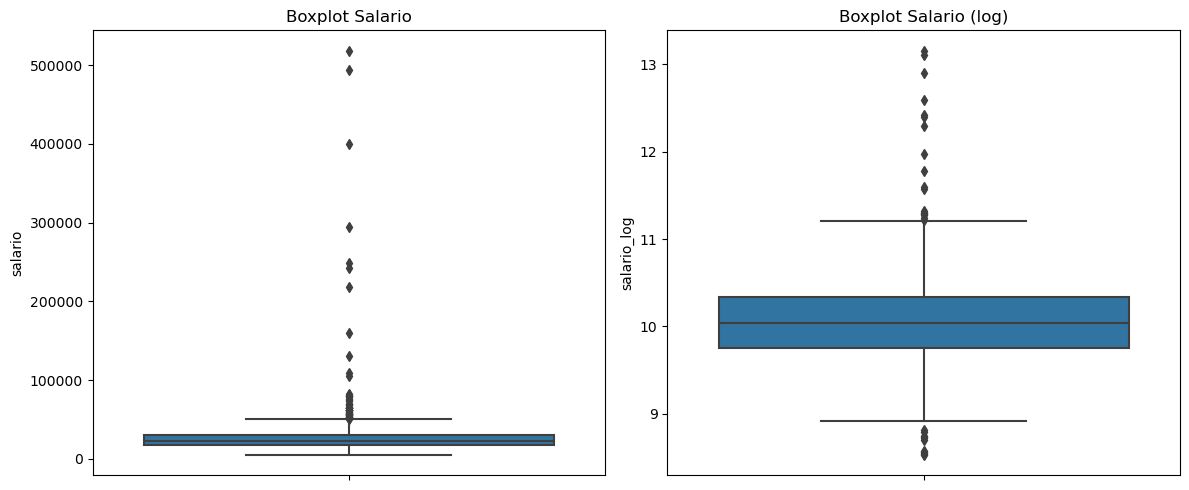

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Crear columna salario_log
datos['salario_log'] = np.log(datos['salario'])

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Boxplot salario
sns.boxplot(y=datos['salario'], ax=axes[0])
axes[0].set_title("Boxplot Salario")

# Boxplot salario_log
sns.boxplot(y=datos['salario_log'], ax=axes[1])
axes[1].set_title("Boxplot Salario (log)")

plt.tight_layout()
plt.show()

In [30]:
import numpy as np

# Crear columna salario_log
datos['salario_log'] = np.log(datos['salario'])

# Estadísticas descriptivas de ambas variables
print(datos[['salario', 'salario_log']].describe())

             salario  salario_log
count    1000.000000  1000.000000
mean    28034.045502    10.058588
std     31587.509082     0.529467
min      5063.461821     8.529806
25%     17302.193253     9.758589
50%     22873.099837    10.037717
75%     30819.419609    10.335900
max    518367.294681    13.158439


In [31]:
print("Salario:")
print(f"Media: {datos['salario'].mean():.2f}")
print(f"Mediana: {datos['salario'].median():.2f}")
print(f"Varianza: {datos['salario'].var():.2f}")
print(f"Desviación estándar: {datos['salario'].std():.2f}")

print("\nSalario_log:")
print(f"Media: {datos['salario_log'].mean():.2f}")
print(f"Mediana: {datos['salario_log'].median():.2f}")
print(f"Varianza: {datos['salario_log'].var():.2f}")
print(f"Desviación estándar: {datos['salario_log'].std():.2f}")

Salario:
Media: 28034.05
Mediana: 22873.10
Varianza: 997770730.01
Desviación estándar: 31587.51

Salario_log:
Media: 10.06
Mediana: 10.04
Varianza: 0.28
Desviación estándar: 0.53
